# Data Loading and Initial Exploration

In [13]:
import pandas as pd

# --- Load the dataset ---
try:
    df = pd.read_csv('/content/raksha-farmer-query.csv')
    print("Dataset reloaded successfully.")

    # Fill nulls in 'QueryText' with an empty string
    if 'QueryText' in df.columns:
        df['QueryText'] = df['QueryText'].fillna('')
        print("Filled null values in 'QueryText' column with empty strings.")
    else:
        print("'QueryText' column not found.")

    # Report on nulls in other columns. We will not perform a global dropna as it empties the DataFrame.
    print("\nChecking for nulls in other columns:")
    other_column_nulls = df.drop(columns=['QueryText'], errors='ignore').isnull().sum()
    other_column_nulls = other_column_nulls[other_column_nulls > 0]
    if not other_column_nulls.empty:
        print("Warning: Null values still exist in the following columns:")
        print(other_column_nulls)
        print("A global `dropna()` would remove all rows as every row has at least one null outside 'QueryText'.")
        print("Proceeding without dropping rows based on these other nulls to preserve data for 'QueryText' analysis.")
    else:
        print("No other columns have null values after handling 'QueryText'.")

except FileNotFoundError:
    print("Error: The specified dataset was not found. Please check the file path.")
    df = None

Dataset reloaded successfully.
Filled null values in 'QueryText' column with empty strings.

Checking for nulls in other columns:
Season    2000
dtype: int64
A global `dropna()` would remove all rows as every row has at least one null outside 'QueryText'.
Proceeding without dropping rows based on these other nulls to preserve data for 'QueryText' analysis.


## First 10 Rows

In [2]:
if df is not None:
    display(df.head(10))

## Dataset Shape

In [3]:
if df is not None:
    print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

## Dataset Information

In [4]:
if df is not None:
    df.info()

## Missing Values Count

In [5]:
if df is not None:
    missing_values = df.isnull().sum()
    print("Missing values per column:")
    print(missing_values[missing_values > 0])
    if (missing_values == 0).all():
        print("No missing values found in the dataset.")

## Data Cleaning

### Removing Null Values

In [14]:
# The general null value removal (`df.dropna()`) is not performed to avoid emptying the DataFrame.
# Nulls in 'QueryText' were handled by filling with empty strings during dataset loading.
if df is not None:
    print(f"Dataset currently has {df.shape[0]} rows after initial loading and 'QueryText' null handling.")
else:
    print("DataFrame is empty, cannot proceed with cleaning.")

Dataset currently has 2000 rows after initial loading and 'QueryText' null handling.


### Removing Duplicate Rows

In [8]:
if df is not None:
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    rows_after_duplicate_removal = df.shape[0]
    print(f"Removed {initial_rows - rows_after_duplicate_removal} duplicate rows.")
    print(f"Dataset now has {rows_after_duplicate_removal} rows.")

Removed 0 duplicate rows.
Dataset now has 0 rows.


### Cleaning 'QueryText' Column

In [9]:
if df is not None and 'QueryText' in df.columns:
    # Convert text to lowercase
    df['QueryText'] = df['QueryText'].str.lower()
    print("Converted 'QueryText' to lowercase.")

    # Remove special characters and numbers
    df['QueryText'] = df['QueryText'].str.replace(r'[^a-z\s]', '', regex=True)
    print("Removed special characters and numbers from 'QueryText'.")
else:
    print("'QueryText' column not found or DataFrame is empty. Skipping text cleaning.")

Converted 'QueryText' to lowercase.
Removed special characters and numbers from 'QueryText'.


## Cleaned Dataset Sample

In [10]:
if df is not None:
    display(df.head())

,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,CreatedOn,year,month


## Exploratory Data Analysis (EDA)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    print(f"Current DataFrame shape: {df.shape}")
else:
    print("DataFrame is empty, cannot perform EDA.")

Current DataFrame shape: (2000, 12)


### Category Distribution

/tmp/ipykernel_5637/1995571580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')


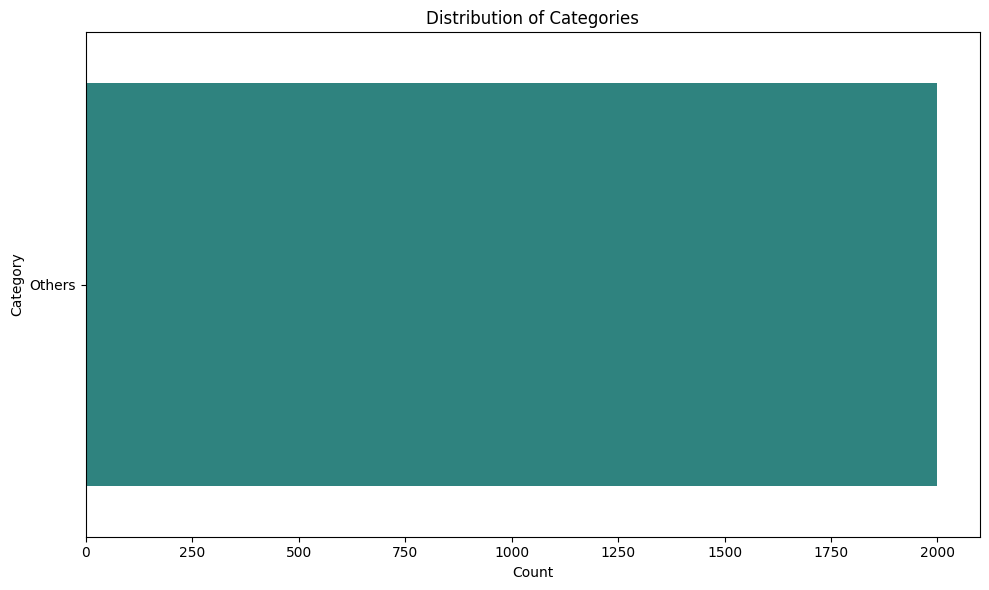

In [16]:
if df is not None and 'Category' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
    plt.title('Distribution of Categories')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()
else:
    print("'Category' column not found or DataFrame is empty. Skipping category distribution.")

### State-wise Distribution

/tmp/ipykernel_5637/2138833012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='StateName', data=df, order=df['StateName'].value_counts().index, palette='plasma')


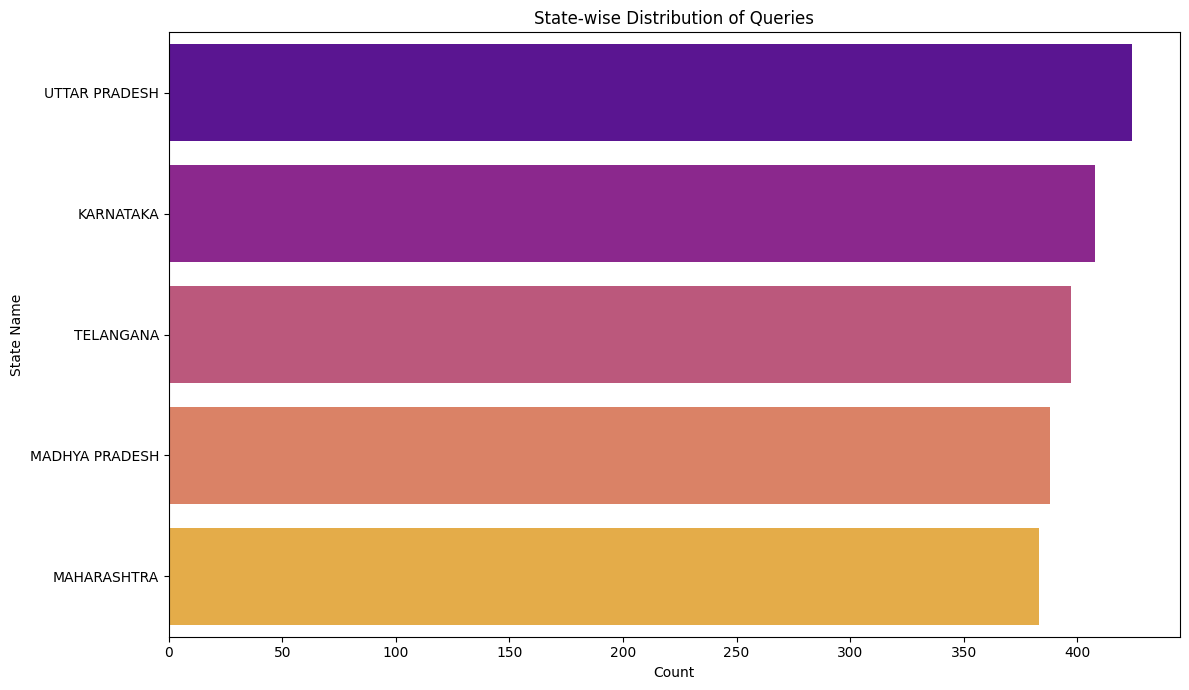

In [17]:
if df is not None and 'StateName' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.countplot(y='StateName', data=df, order=df['StateName'].value_counts().index, palette='plasma')
    plt.title('State-wise Distribution of Queries')
    plt.xlabel('Count')
    plt.ylabel('State Name')
    plt.tight_layout()
    plt.show()
else:
    print("'StateName' column not found or DataFrame is empty. Skipping state-wise distribution.")

### Season-wise Distribution

/tmp/ipykernel_5637/1608344807.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Season', data=df_season_plot, order=df_season_plot['Season'].value_counts().index, palette='coolwarm')


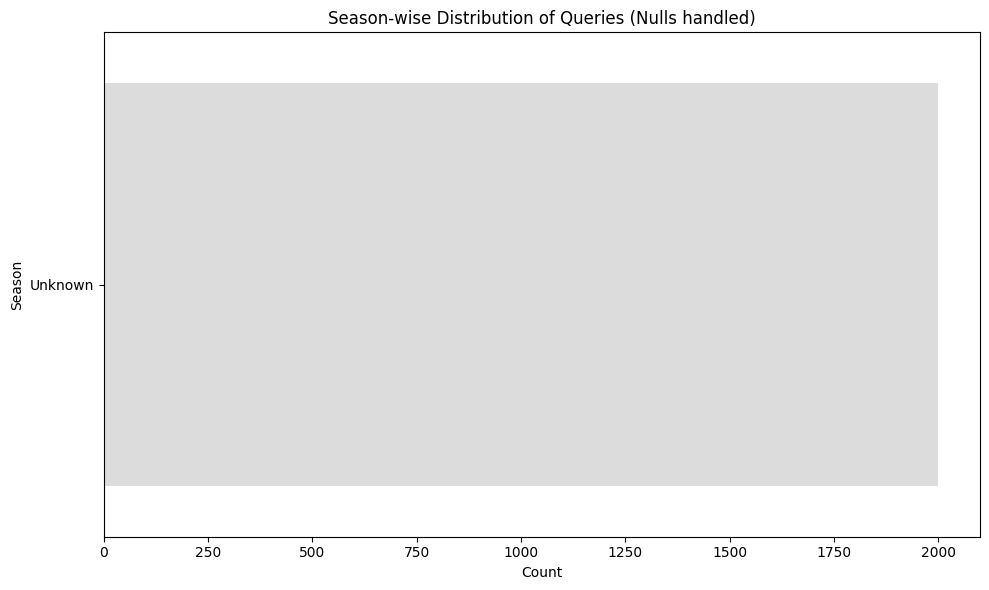

In [18]:
if df is not None and 'Season' in df.columns:
    # Fill null 'Season' values with 'Unknown' for plotting purposes
    df_season_plot = df.copy()
    df_season_plot['Season'] = df_season_plot['Season'].fillna('Unknown')

    plt.figure(figsize=(10, 6))
    sns.countplot(y='Season', data=df_season_plot, order=df_season_plot['Season'].value_counts().index, palette='coolwarm')
    plt.title('Season-wise Distribution of Queries (Nulls handled)')
    plt.xlabel('Count')
    plt.ylabel('Season')
    plt.tight_layout()
    plt.show()
else:
    print("'Season' column not found or DataFrame is empty. Skipping season-wise distribution.")

### Monthly Trend

/tmp/ipykernel_5637/3301684938.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='cubehelix')


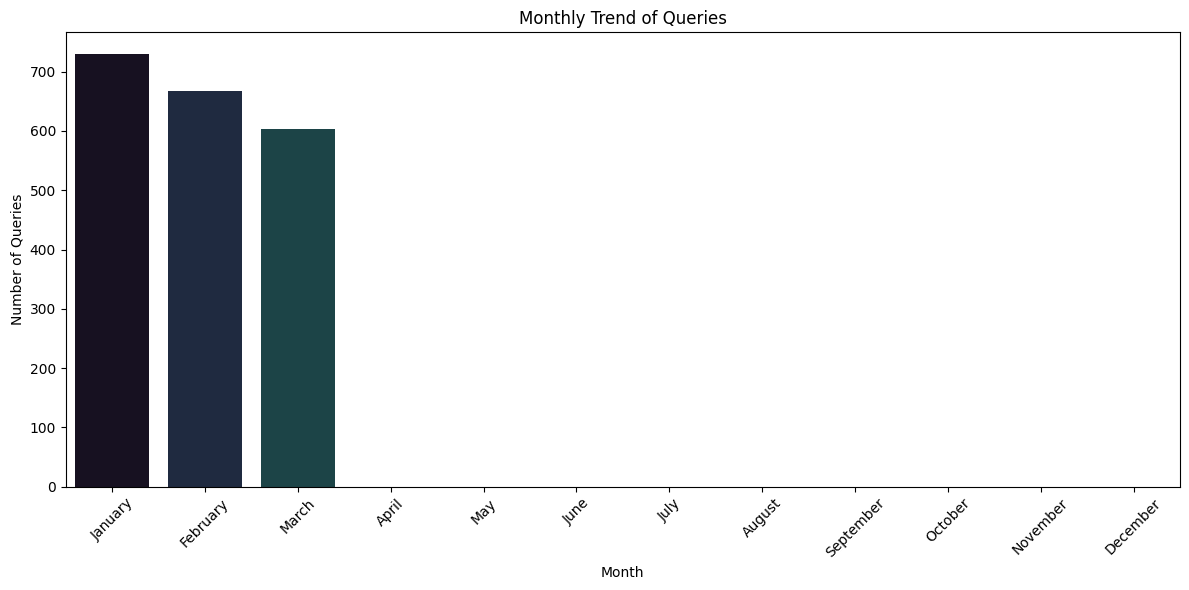

In [19]:
if df is not None and 'month' in df.columns:
    # Ensure 'month' is numeric or convertible to a month name
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

    # Map month numbers to names for better readability, if 'month' is numeric
    if pd.api.types.is_numeric_dtype(df['month']):
        df_monthly = df.copy()
        df_monthly['month_name'] = df_monthly['month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))
        monthly_counts = df_monthly['month_name'].value_counts().reindex(month_order, fill_value=0)
    else:
        # If 'month' is already string (e.g., 'March'), use it directly
        monthly_counts = df['month'].value_counts().reindex(month_order, fill_value=0)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='cubehelix')
    plt.title('Monthly Trend of Queries')
    plt.xlabel('Month')
    plt.ylabel('Number of Queries')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("'month' column not found or DataFrame is empty. Skipping monthly trend analysis.")

## NLP Preprocessing: TF-IDF Vectorization

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

if df is not None and 'QueryText' in df.columns:
    # Initialize TF-IDF Vectorizer
    # You can adjust parameters like max_features, min_df, max_df, ngram_range etc.
    tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    # Fit and transform the 'QueryText' column
    # Ensure QueryText is treated as strings; fillna('') was already done
    tfidf_matrix = tfidf_vectorizer.fit_transform(df['QueryText'].astype(str))

    print("TF-IDF vectorization complete.")

    # Print shape of transformed data
    print(f"Shape of transformed TF-IDF data: {tfidf_matrix.shape}")

    # Show sample feature names
    print("\nSample TF-IDF feature names (top 20):")
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print(feature_names[:20])
else:
    print("'QueryText' column not found or DataFrame is empty. Skipping TF-IDF vectorization.")

TF-IDF vectorization complete.
Shape of transformed TF-IDF data: (2000, 94)

Sample TF-IDF feature names (top 20):
['agristack' 'aphids' 'application' 'asked' 'attack' 'bengal' 'bima'
 'blight' 'card' 'chilli' 'citrus' 'control' 'cotton' 'credit' 'crop'
 'disease' 'dose' 'doses' 'drip' 'famer']


## Re-evaluating Classification with `QueryType` as Target

### Checking 'QueryType' Column Diversity

In [25]:
if df is not None and 'QueryType' in df.columns:
    print("Value counts for 'QueryType' column:")
    print(df['QueryType'].value_counts(dropna=False))
    print(f"\nNumber of unique QueryTypes: {df['QueryType'].nunique()}")

    if df['QueryType'].nunique() < 2:
        print("Warning: 'QueryType' column has less than 2 unique classes. Cannot perform meaningful classification.")
    else:
        print("'QueryType' is suitable for classification.")
else:
    print("'QueryType' column not found or DataFrame is empty. Cannot proceed with classification.")

Value counts for 'QueryType' column:
QueryType
Market                 357
Plant Protection       348
Weather                334
Government Schemes     334
Nutrient Management    323
Seeds                  304
Name: count, dtype: int64

Number of unique QueryTypes: 6
'QueryType' is suitable for classification.


### Splitting Data into Training and Testing Sets (Target: `QueryType`)

In [26]:
from sklearn.model_selection import train_test_split

if df is not None and 'QueryType' in df.columns and df['QueryType'].nunique() >= 2:
    X = tfidf_matrix
    y = df['QueryType']

    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nShape of X_train: {X_train.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of y_test: {y_test.shape}")
else:
    print("Data not prepared for splitting or 'QueryType' column is unsuitable.")



Shape of X_train: (1600, 94)
Shape of X_test: (400, 94)
Shape of y_train: (1600,)
Shape of y_test: (400,)


### Training Logistic Regression Model (Target: `QueryType`)

Training Logistic Regression model for QueryType...
Logistic Regression model trained.

Logistic Regression Accuracy (QueryType): 0.1875

Logistic Regression Classification Report (QueryType):
                     precision    recall  f1-score   support

 Government Schemes       0.22      0.31      0.26        67
             Market       0.16      0.20      0.17        71
Nutrient Management       0.19      0.23      0.21        64
   Plant Protection       0.27      0.19      0.22        70
              Seeds       0.17      0.07      0.09        61
            Weather       0.13      0.12      0.12        67

           accuracy                           0.19       400
          macro avg       0.19      0.19      0.18       400
       weighted avg       0.19      0.19      0.18       400



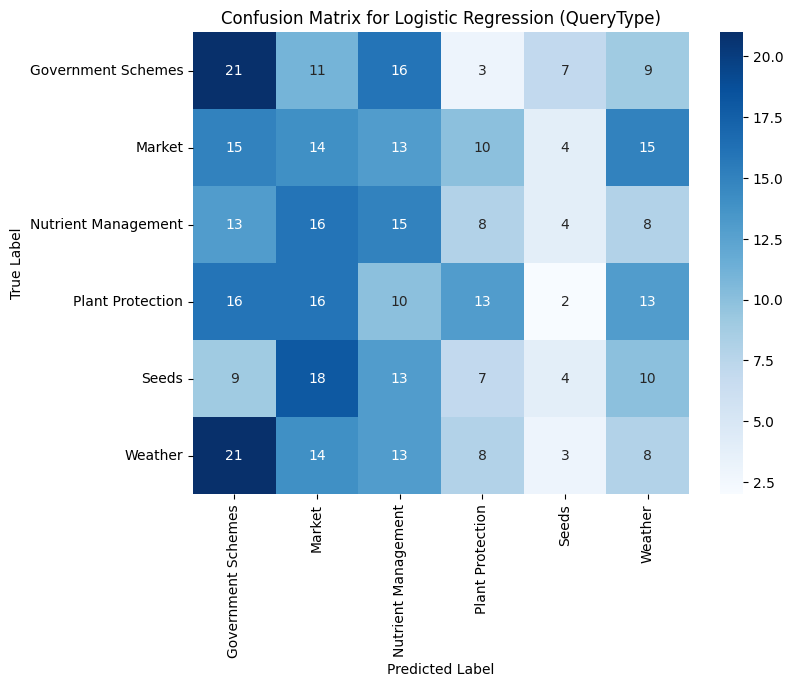

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if 'QueryType' in df.columns and df['QueryType'].nunique() >= 2 and X_train is not None:
    # Initialize Logistic Regression model
    # Increased max_iter for convergence, using 'liblinear' solver which is good for small datasets
    log_reg_qt = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

    # Train the model
    print("Training Logistic Regression model for QueryType...")
    log_reg_qt.fit(X_train, y_train)
    print("Logistic Regression model trained.")

    # Make predictions on the test set
    y_pred_qt = log_reg_qt.predict(X_test)

    # Evaluate the model
    accuracy_qt = accuracy_score(y_test, y_pred_qt)
    print(f"\nLogistic Regression Accuracy (QueryType): {accuracy_qt:.4f}")

    print("\nLogistic Regression Classification Report (QueryType):")
    print(classification_report(y_test, y_pred_qt))

    # Display Confusion Matrix
    cm_qt = confusion_matrix(y_test, y_pred_qt)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_qt, annot=True, fmt='d', cmap='Blues',
                xticklabels=log_reg_qt.classes_, yticklabels=log_reg_qt.classes_)
    plt.title('Confusion Matrix for Logistic Regression (QueryType)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("Data not prepared for Logistic Regression or 'QueryType' column is unsuitable.")

### Training Random Forest Classifier (Target: `QueryType`)

Training Random Forest Classifier model for QueryType...
Random Forest Classifier model trained.

Random Forest Classifier Accuracy (QueryType): 0.1675

Random Forest Classifier Classification Report (QueryType):
                     precision    recall  f1-score   support

 Government Schemes       0.17      0.16      0.17        67
             Market       0.23      0.30      0.26        71
Nutrient Management       0.14      0.14      0.14        64
   Plant Protection       0.24      0.19      0.21        70
              Seeds       0.08      0.07      0.07        61
            Weather       0.12      0.13      0.13        67

           accuracy                           0.17       400
          macro avg       0.16      0.16      0.16       400
       weighted avg       0.16      0.17      0.16       400



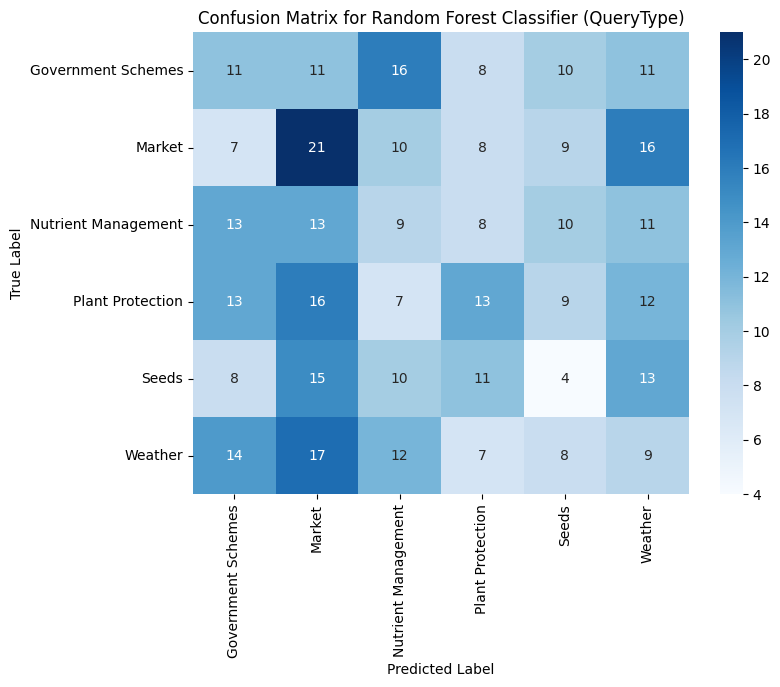

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if 'QueryType' in df.columns and df['QueryType'].nunique() >= 2 and X_train is not None:
    # Initialize Random Forest Classifier model
    rf_classifier_qt = RandomForestClassifier(n_estimators=100, random_state=42)

    # Train the model
    print("Training Random Forest Classifier model for QueryType...")
    rf_classifier_qt.fit(X_train, y_train)
    print("Random Forest Classifier model trained.")

    # Make predictions on the test set
    y_pred_rf_qt = rf_classifier_qt.predict(X_test)

    # Evaluate the model
    accuracy_rf_qt = accuracy_score(y_test, y_pred_rf_qt)
    print(f"\nRandom Forest Classifier Accuracy (QueryType): {accuracy_rf_qt:.4f}")

    print("\nRandom Forest Classifier Classification Report (QueryType):")
    print(classification_report(y_test, y_pred_rf_qt))

    # Display Confusion Matrix
    cm_rf_qt = confusion_matrix(y_test, y_pred_rf_qt)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_rf_qt, annot=True, fmt='d', cmap='Blues',
                xticklabels=rf_classifier_qt.classes_, yticklabels=rf_classifier_qt.classes_)
    plt.title('Confusion Matrix for Random Forest Classifier (QueryType)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("Data not prepared for Random Forest Classifier or 'QueryType' column is unsuitable.")

## Detailed Farmer Query Analysis

### Data Preparation for Trend Analysis

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None and 'CreatedOn' in df.columns:
    # Convert 'CreatedOn' to datetime objects
    df['CreatedOn'] = pd.to_datetime(df['CreatedOn'])
    print("Converted 'CreatedOn' column to datetime format.")

    # Extract month and year for trend analysis
    df['query_month'] = df['CreatedOn'].dt.month_name()
    df['query_year'] = df['CreatedOn'].dt.year
    print("Extracted 'query_month' and 'query_year' for trend analysis.")
else:
    print("'CreatedOn' column not found or DataFrame is empty. Skipping date preparation.")

Converted 'CreatedOn' column to datetime format.
Extracted 'query_month' and 'query_year' for trend analysis.


### Distribution of `QueryType`

/tmp/ipykernel_5637/2976190933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='QueryType', data=df, order=df['QueryType'].value_counts().index, palette='viridis')


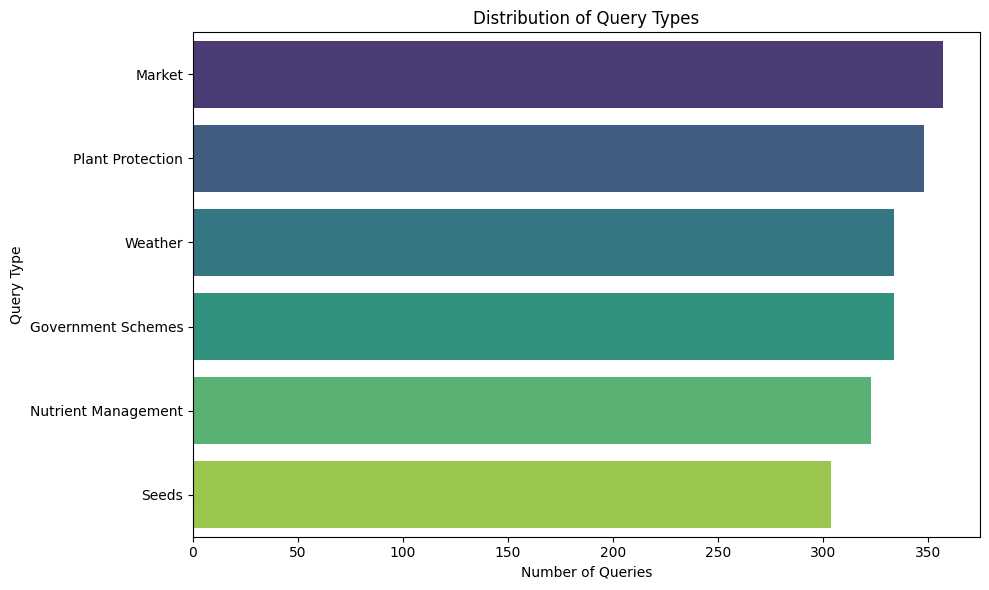

In [30]:
if df is not None and 'QueryType' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y='QueryType', data=df, order=df['QueryType'].value_counts().index, palette='viridis')
    plt.title('Distribution of Query Types')
    plt.xlabel('Number of Queries')
    plt.ylabel('Query Type')
    plt.tight_layout()
    plt.show()
else:
    print("'QueryType' column not found or DataFrame is empty. Skipping QueryType distribution.")

#### Insights: QueryType Distribution
This bar chart shows the frequency of each `QueryType`. We can observe which types of queries are most common among farmers. This insight can help in allocating resources or developing more targeted information for specific query categories.

### Top 10 States with Highest Number of Queries

/tmp/ipykernel_5637/1365626556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_states.values, y=top_10_states.index, palette='plasma')


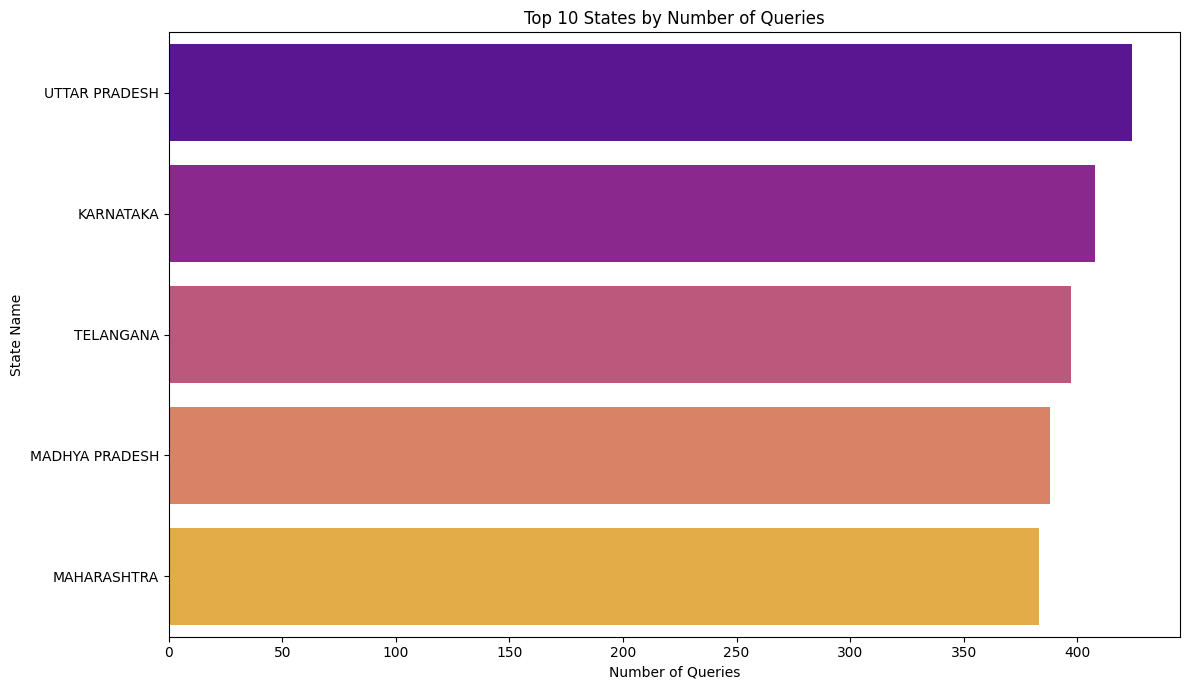

In [31]:
if df is not None and 'StateName' in df.columns:
    top_10_states = df['StateName'].value_counts().nlargest(10)
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_10_states.values, y=top_10_states.index, palette='plasma')
    plt.title('Top 10 States by Number of Queries')
    plt.xlabel('Number of Queries')
    plt.ylabel('State Name')
    plt.tight_layout()
    plt.show()
else:
    print("'StateName' column not found or DataFrame is empty. Skipping top states analysis.")

#### Insights: Top 10 States
This chart highlights the states generating the most queries. Identifying these states can guide regional outreach programs, resource deployment, and localized support services. A high volume from a particular state might indicate specific agricultural challenges or a greater awareness of available resources.

### Top 10 Districts with Highest Number of Queries

/tmp/ipykernel_5637/3226733012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_districts.values, y=top_10_districts.index, palette='cubehelix')


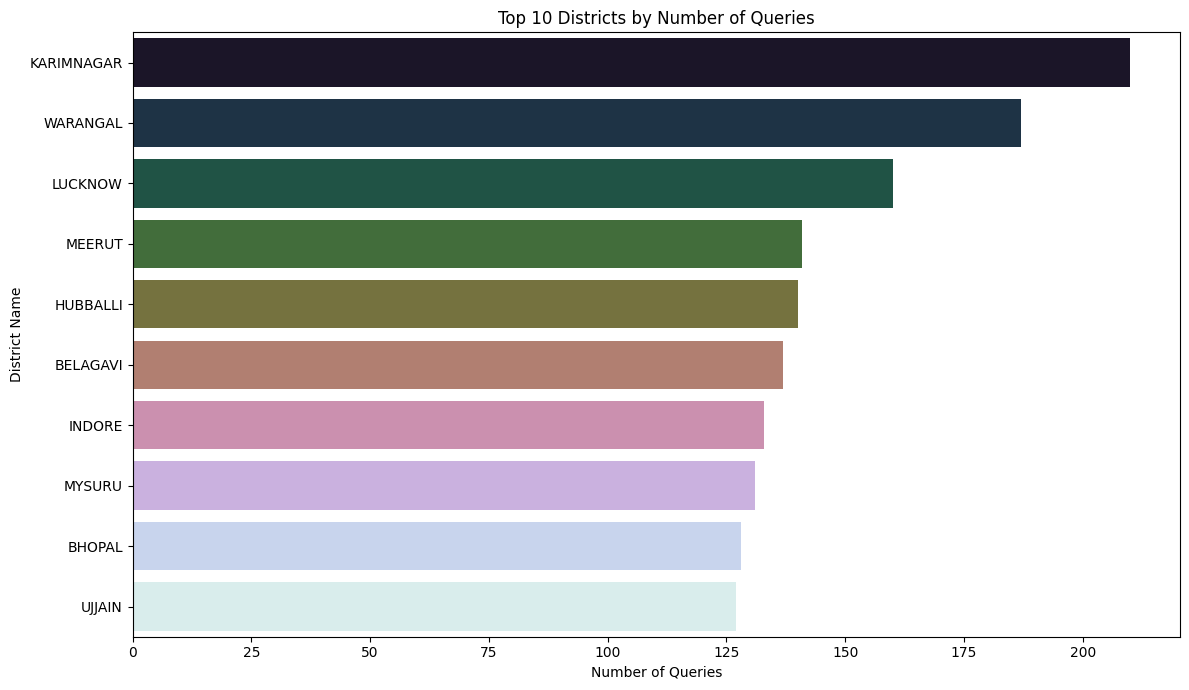

In [32]:
if df is not None and 'DistrictName' in df.columns:
    top_10_districts = df['DistrictName'].value_counts().nlargest(10)
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_10_districts.values, y=top_10_districts.index, palette='cubehelix')
    plt.title('Top 10 Districts by Number of Queries')
    plt.xlabel('Number of Queries')
    plt.ylabel('District Name')
    plt.tight_layout()
    plt.show()
else:
    print("'DistrictName' column not found or DataFrame is empty. Skipping top districts analysis.")

#### Insights: Top 10 Districts
Similar to states, focusing on the top districts can help in hyper-localizing support and interventions. These districts may require more attention in terms of agricultural extension services, information dissemination, or addressing specific local issues reflected in the queries.

### Monthly Query Trends using `CreatedOn`

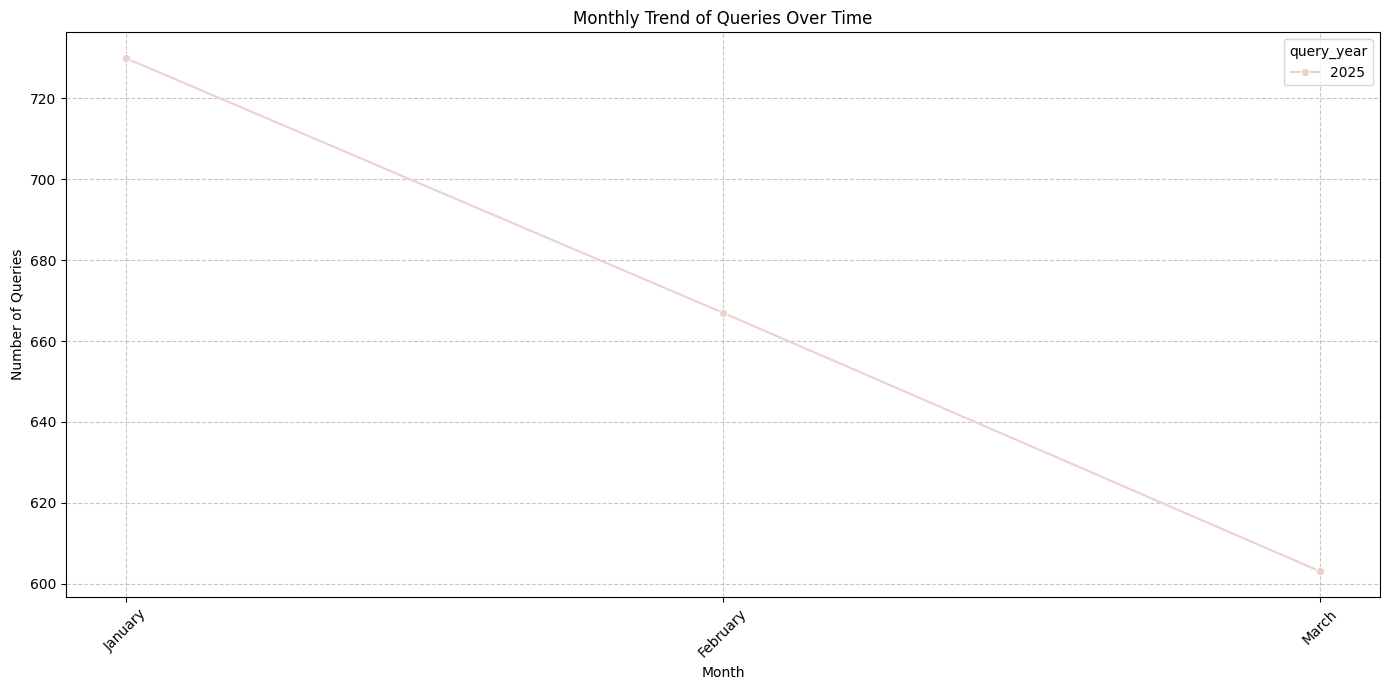

In [33]:
if df is not None and 'query_month' in df.columns and 'query_year' in df.columns:
    # Order months correctly for plotting
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

    # Group by year and month to get query counts
    monthly_trends = df.groupby(['query_year', 'query_month']).size().reset_index(name='query_count')
    monthly_trends['query_month'] = pd.Categorical(monthly_trends['query_month'], categories=month_order, ordered=True)
    monthly_trends = monthly_trends.sort_values(['query_year', 'query_month'])

    plt.figure(figsize=(14, 7))
    sns.lineplot(x='query_month', y='query_count', hue='query_year', data=monthly_trends, marker='o')
    plt.title('Monthly Trend of Queries Over Time')
    plt.xlabel('Month')
    plt.ylabel('Number of Queries')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("'query_month' or 'query_year' columns not found or DataFrame is empty. Skipping monthly trend analysis.")

#### Insights: Monthly Query Trends
This line chart illustrates how the number of queries changes over different months and years. Seasonal patterns related to cropping cycles, weather events, or government policies might emerge. For example, a spike in queries during planting or harvesting seasons could indicate common challenges faced by farmers at those times. This trend analysis helps in predicting peak periods for queries and preparing resources accordingly.

## Farmer Query Prediction Function

In [34]:
import re

def predict_query_type(query_text):
    """
    Predicts the QueryType for a given farmer query using the trained Logistic Regression model.

    Args:
        query_text (str): The raw farmer query string.

    Returns:
        str: The predicted QueryType.
    """
    if log_reg_qt is None or tfidf_vectorizer is None:
        return "Error: Model or vectorizer not trained/available."

    # Preprocessing the input query (same steps as training data)
    cleaned_query = query_text.lower()
    cleaned_query = re.sub(r'[^a-z\s]', '', cleaned_query)

    # Vectorize the cleaned query
    query_vector = tfidf_vectorizer.transform([cleaned_query])

    # Predict the QueryType
    predicted_type = log_reg_qt.predict(query_vector)[0]

    return predicted_type

print("Prediction function `predict_query_type` created.")

Prediction function `predict_query_type` created.


### Test the Prediction Function with Example Queries

In [35]:
example_queries = [
    "What is the current market price for rice in Karnataka?",
    "How to control pests in chili plants?",
    "Information about government schemes for farmers in Uttar Pradesh.",
    "When is the best time to sow wheat seeds?",
    "What are the weather conditions expected next week in my district?"
]

print("\n--- Prediction Results ---")
for i, query in enumerate(example_queries):
    predicted_type = predict_query_type(query)
    print(f"Query {i+1}: '{query}'")
    print(f"Predicted QueryType: {predicted_type}\n")


--- Prediction Results ---
Query 1: 'What is the current market price for rice in Karnataka?'
Predicted QueryType: Weather

Query 2: 'How to control pests in chili plants?'
Predicted QueryType: Plant Protection

Query 3: 'Information about government schemes for farmers in Uttar Pradesh.'
Predicted QueryType: Plant Protection

Query 4: 'When is the best time to sow wheat seeds?'
Predicted QueryType: Market

Query 5: 'What are the weather conditions expected next week in my district?'
Predicted QueryType: Market



In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   StateName     2000 non-null   object        
 1   DistrictName  2000 non-null   object        
 2   BlockName     2000 non-null   object        
 3   Season        0 non-null      float64       
 4   Sector        2000 non-null   object        
 5   Category      2000 non-null   object        
 6   Crop          2000 non-null   object        
 7   QueryType     2000 non-null   object        
 8   QueryText     2000 non-null   object        
 9   CreatedOn     2000 non-null   datetime64[ns]
 10  year          2000 non-null   int64         
 11  month         2000 non-null   int64         
 12  query_month   2000 non-null   object        
 13  query_year    2000 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(9)
memory usage: 211.1+ KB
